Running a paired LQR vs LQG experiment (same noise for both)...

Theory: State Trajectory Comparison (True states, e_y vs psi)
This plot shows true system trajectories projected on (lateral offset e_y, yaw psi).
LQR uses the full true state in the control law (perfect state knowledge). LQG uses a Kalman filter estimate.
Differences in paths reveal how estimation errors and measurement noise influence closed-loop behavior.



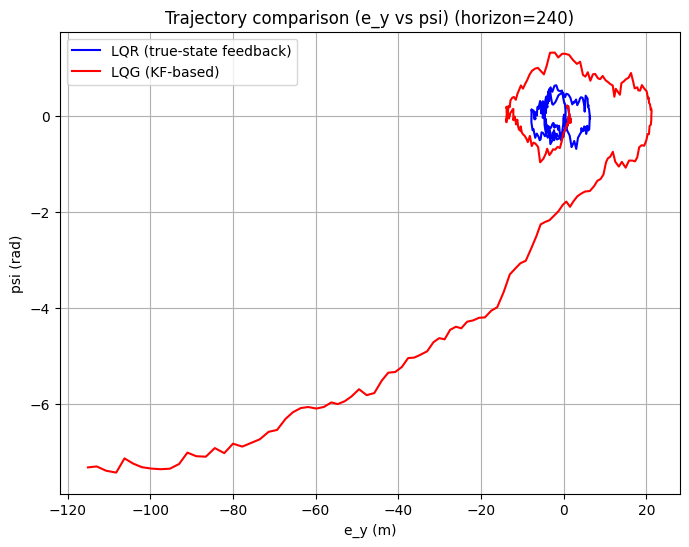


Theory: Estimation Error (KF Performance)
This shows the Kalman filter's estimation error (true state - estimate) over time.
Small, zero-mean, bounded errors indicate a well-tuned observer. Large bias or growth indicates poor model/noise tuning.



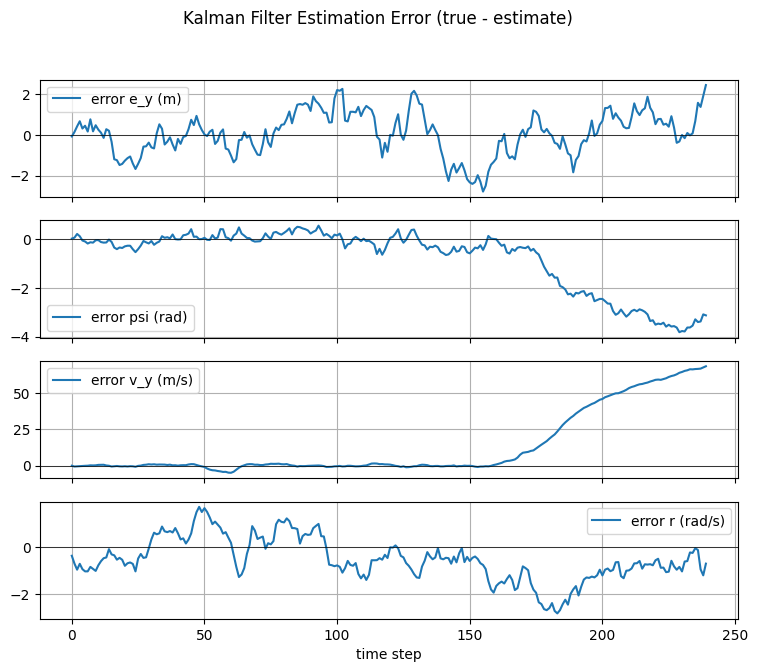


Theory: Control Input Comparison
Control input sequences (steering) illustrate how much control effort each method uses.
LQG may use different steering because it acts on estimated states; differences also reflect estimator delay/noise.



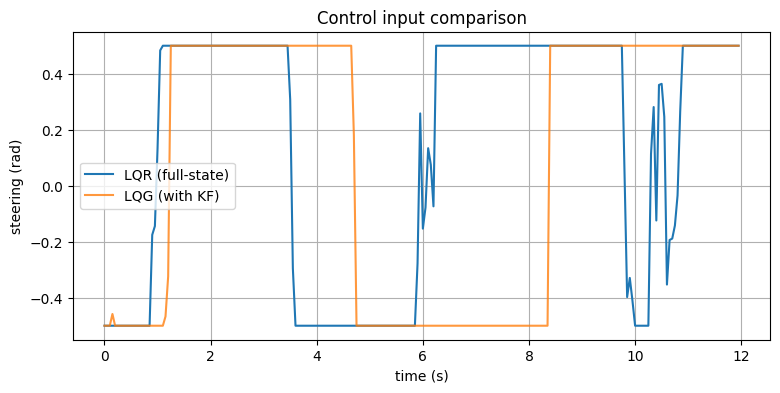


Theory: Instantaneous & Cumulative Cost
Instantaneous cost = x^T Q x + u^T R u per time-step.
Cumulative cost shows which controller attains lower total objective J across the horizon.
Lower cumulative cost indicates better regulation under the given Q,R and noise.



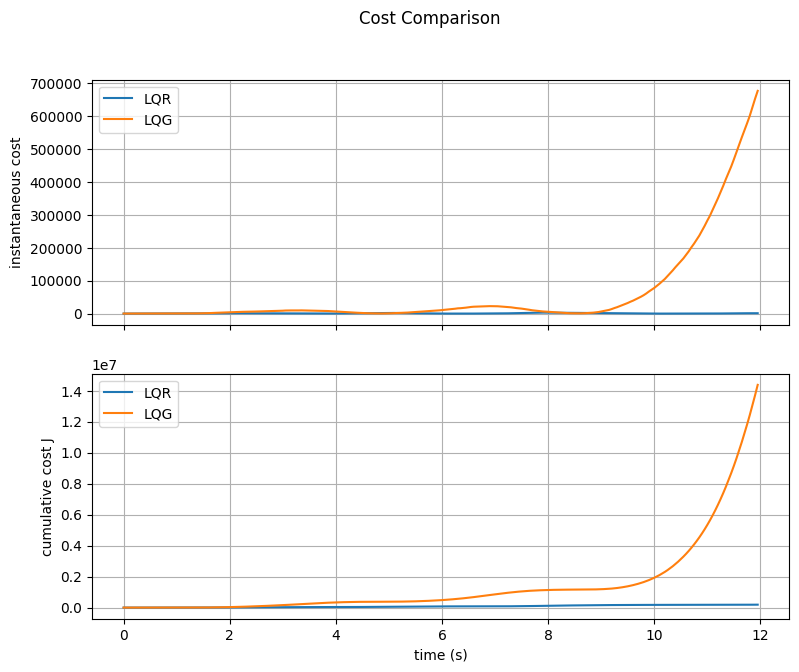


Run Summary (numeric)
Final cumulative cost: LQR = 188450.5127, LQG = 14379992.2811
Control energy (sum u^2): LQR = 54.5943, LQG = 59.5656
Estimator RMSE (e_y, psi, v_y, r): [ 1.0434  1.4899 25.9699  1.05  ]


Theory: Paired Monte Carlo Comparison
We run 'trials' paired experiments. Each trial uses the exact same sequence of process and measurement noise
for both LQR and LQG, so differences are caused only by the controller/estimator interactions.
We collect total cost and control-energy and show histograms & summary statistics.

MC trials done in 1.3s

Monte Carlo summary (mean ± std):
Control energy LQR: 38.3383 ± 2.0526
Control energy LQG: 38.8419 ± 1.0418
Total cost LQR: 2628017.3111 ± 3810376.0884
Total cost LQG: 3173029.5031 ± 3451310.5964


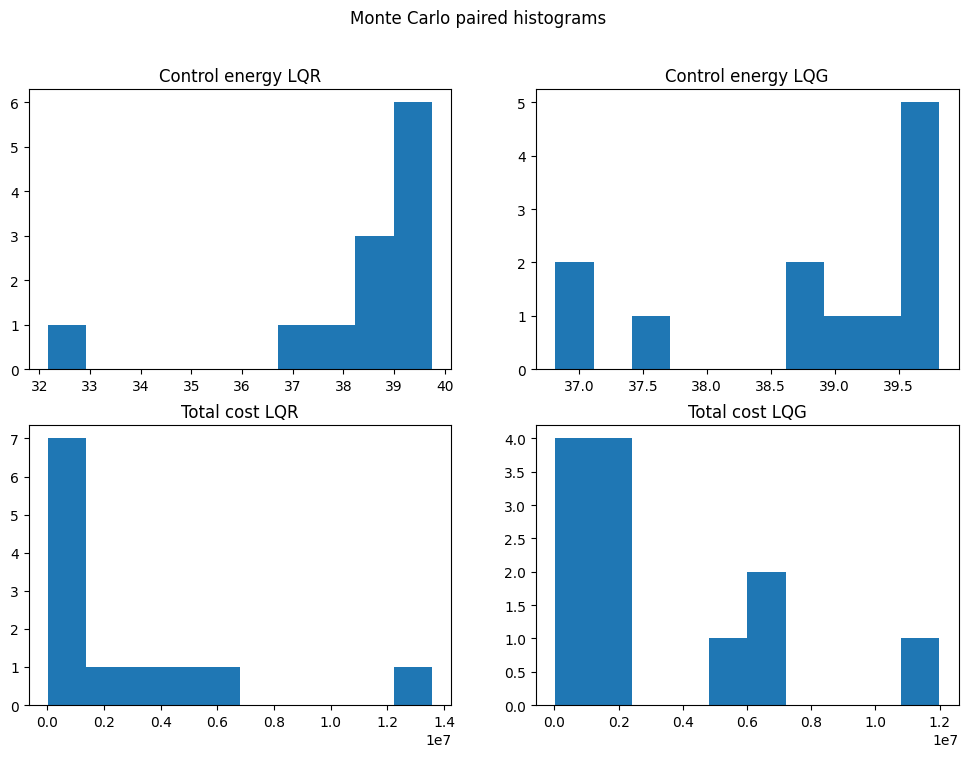


Done. Tips:
 - To see stronger LQG advantage, increase measurement noise (Rv) in simulate_pair.
 - To test model mismatch, change tire parameters between linearization and true plant (e.g., vary C_f0).


In [ ]:
"""
tv_lqr_vs_lqg_compare.py

Merged TV-LQR vs LQG comparison script.

Features:
 - Nonlinear bicycle model with simple tire saturation nonlinearity
 - Finite-difference linearization + ZOH discretization
 - Finite-horizon time-varying LQR (backward Riccati recursion)
 - Discrete-time Kalman filter (predict/update)
 - Paired simulations with identical noise draws for fair LQR vs LQG comparison
 - Multiple comparison plots with short theory text printed before each figure
 - Monte Carlo paired comparison summary (control-energy & cost)
"""

import numpy as np
from scipy import linalg
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import time

np.random.seed(0)

# -------------------------
# Utility
# -------------------------
def wrap_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def plot_cov_ellipse(ax, mean, cov, nstd=2.0, facecolor='none', **kwargs):
    cov = (cov + cov.T) * 0.5
    vals, vecs = linalg.eigh(cov)
    vals = np.clip(vals, 1e-12, None)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width, height = 2 * nstd * np.sqrt(vals[:2])
    ell = Ellipse(xy=(mean[0], mean[1]), width=width, height=height, angle=theta,
                  facecolor=facecolor, **kwargs)
    ax.add_patch(ell)
    return ell

# -------------------------
# Nonlinear bicycle model
# -------------------------
m = 1500.0
I_z = 3000.0
l_f = 1.2
l_r = 1.6
C_f0 = 80000.0
C_r0 = 80000.0
v_x = 15.0        # longitudinal speed (m/s)
Ts_default = 0.05

def tire_stiffness(alpha, C0=80000.0):
    k = 5.0
    return C0 * np.exp(-k * np.abs(alpha))

def nonlinear_bicycle(x, u):
    e_y, psi, v_y, r = x
    delta = float(u[0]) if hasattr(u, "__len__") else float(u)
    alpha_f = (v_y + l_f * r) / v_x - delta
    alpha_r = (v_y - l_r * r) / v_x
    C_f = tire_stiffness(alpha_f, C_f0)
    C_r = tire_stiffness(alpha_r, C_r0)
    F_yf = -2.0 * C_f * alpha_f
    F_yr = -2.0 * C_r * alpha_r
    e_y_dot = v_y + v_x * psi
    psi_dot = r
    v_y_dot = (F_yf + F_yr) / m - v_x * r
    r_dot = (l_f * F_yf - l_r * F_yr) / I_z
    return np.array([e_y_dot, psi_dot, v_y_dot, r_dot])

# -------------------------
# Linearize & discretize
# -------------------------
def linearize(x, u, eps=1e-6):
    x = x.astype(float)
    u = np.atleast_1d(u).astype(float)
    n = x.size
    mu = u.size
    f0 = nonlinear_bicycle(x, u)
    A = np.zeros((n, n))
    B = np.zeros((n, mu))
    for i in range(n):
        dx = np.zeros_like(x); dx[i] = eps
        A[:, i] = (nonlinear_bicycle(x + dx, u) - f0) / eps
    for j in range(mu):
        du = np.zeros_like(u); du[j] = eps
        B[:, j] = (nonlinear_bicycle(x, u + du) - f0) / eps
    return A, B
def successive_difference_approximation(x1,x2,t1,t2):
  y = (x2-x1)/(t1-t2)
  return y

def approximate_by_shooting_algo(cost_fun , f_x ,lambda1, lambda0 = 0.1, x_target=0.0, tol=1e-6, max_iter=50):
    H1 = cost_fun(f_x) + lambda1 * np.linalg.norm(f_x)**2
    H0 = cost_fun(f_x) + lambda0 * np.linalg.norm(f_x)**2
    x_hat = successive_difference_approximation(H1,H0, lambda1,lambda0)
    x1 = f_x*dt
    x0 = 0
    lamda_hat = successive_difference_approximation(H1,H0,x1,x0)
    #starting the shooting algorithm
    lam0 = lambda0
    lam1 = lambda1
    xT_0 = f_x + x_hat*dt
    xT_1 = f_x + (x_hat+lam0)*dt
    err0 = xT_0 - x_target
    err1 = xT_1 - x_target
    for i in range(max_iter):
      if(abs(err1)<tol):
        print("Converged")
        return lam1, xT_1
      denom = err1




def discretize_linear(Ac, Bc, Ts):
    n = Ac.shape[0]; m = Bc.shape[1]
    M = np.zeros((n + m, n + m))
    M[:n, :n] = Ac
    M[:n, n:] = Bc
    Mexp = expm(M * Ts)
    Ad = Mexp[:n, :n]
    Bd = Mexp[:n, n:]
    return Ad, Bd

# -------------------------
# TV-LQR (backward Riccati)
# -------------------------
def tv_lqr_gains(A_seq, B_seq, Q, R, Qf):
    N = len(A_seq)
    P_seq = [None]*(N+1)
    K_seq = [None]*N
    P_seq[N] = Qf.copy()
    for k in range(N-1, -1, -1):
        A_k = A_seq[k]; B_k = B_seq[k]
        S = R + B_k.T @ P_seq[k+1] @ B_k
        S_inv = linalg.inv(S)
        K_k = S_inv @ (B_k.T @ P_seq[k+1] @ A_k)
        P_k = Q + A_k.T @ P_seq[k+1] @ (A_k - B_k @ K_k)
        P_seq[k] = P_k; K_seq[k] = K_k
    return P_seq, K_seq

# -------------------------
# Discrete Kalman filter
# -------------------------
def discrete_kalman_predict(x, P, A, B, u, Qw):
    x_pred = A @ x + B @ u
    P_pred = A @ P @ A.T + Qw
    return x_pred, P_pred

def discrete_kalman_update(x_pred, P_pred, C, y, Rv):
    S = C @ P_pred @ C.T + Rv
    K_gain = P_pred @ C.T @ linalg.inv(S)
    x_upd = x_pred + K_gain @ (y - C @ x_pred)
    P_upd = (np.eye(P_pred.shape[0]) - K_gain @ C) @ P_pred
    return x_upd, P_upd, K_gain

# Measurement matrix
C_mat = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
])

# -------------------------
# Simulation (paired-noise)
# -------------------------
def simulate_pair(x0, horizon=200, Ts=Ts_default, noise_levels=(1.0,5.0),
                  Q=None, R=None, Qf=None, seed=None, verbose=False):
    """
    Generate a single noise realization (process+measurement) and run:
    - LQR: K_k applied using full true-state (perfect observer)
    - LQG: same K_k applied using Kalman filter estimates
    Returns dict with both results and computed metrics.
    """
    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)

    N = horizon
    x0 = x0.astype(float)
    n = x0.size
    m_u = 1

    if Q is None:
        Q = np.diag([50.0, 200.0, 1.0, 1.0])
    if R is None:
        R = np.array([[10.0]])
    if Qf is None:
        Qf = Q*10.0

    # nominal linearization sequence
    A_seq=[]; B_seq=[]
    x_nom = x0.copy()
    u_nom = np.zeros((N, m_u))
    for k in range(N):
        Ac, Bc = linearize(x_nom, u_nom[k])
        Ad, Bd = discretize_linear(Ac, Bc, Ts)
        A_seq.append(Ad); B_seq.append(Bd)
        x_nom = x_nom + Ts * nonlinear_bicycle(x_nom, u_nom[k])

    P_seq, K_seq = tv_lqr_gains(A_seq, B_seq, Q, R, Qf)

    # noise covs
    Qw = np.diag([0.01, 0.01, 0.05, 0.05]) * float(noise_levels[0])
    Rv = np.diag([0.5, 0.2]) * float(noise_levels[1])

    # sample noise sequences up front (paired)
    w_seq = rng.multivariate_normal(np.zeros(n), Qw, size=N)
    v_seq = rng.multivariate_normal(np.zeros(C_mat.shape[0]), Rv, size=N)

    # containers for both runs
    def run(use_kf):
        x = x0.copy()
        x_est = x0.copy() if use_kf else x0.copy()  # for LQR estimator not used
        P_est = np.eye(n) * 0.1
        x_hist = np.zeros((N, n))
        x_est_hist = np.zeros((N, n))
        P_hist = np.zeros((N, n, n))
        u_hist = np.zeros((N, m_u))
        Kkf_hist = np.zeros((N, n, C_mat.shape[0]))
        for k in range(N):
            Ad = A_seq[k]; Bd = B_seq[k]; Kk = K_seq[k]
            # measurement from true plant (with pre-sampled v)
            y = C_mat @ x + v_seq[k]
            if use_kf:
                u_for_predict = np.zeros((m_u,))
                x_pred, P_pred = discrete_kalman_predict(x_est, P_est, Ad, Bd, u_for_predict, Qw)
                x_est, P_est, Kg = discrete_kalman_update(x_pred, P_pred, C_mat, y, Rv)
            else:
                # LQR uses full state for control (perfect measurement)
                x_est = x.copy()
                P_est = np.eye(n) * 1e-9
                Kg = np.zeros((n, C_mat.shape[0]))
            # control (same K)
            u = (-Kk @ x_est).reshape(m_u)
            u = np.clip(u, -0.5, 0.5)
            # propagate nonlinear plant with pre-sampled process noise
            x = x + Ts * nonlinear_bicycle(x, u) + w_seq[k]
            # store
            x_hist[k,:] = x
            x_est_hist[k,:] = x_est
            P_hist[k,:,:] = P_est
            u_hist[k,:] = u
            Kkf_hist[k,:,:] = Kg
            if verbose and (k % (N//5 + 1) == 0):
                print(f"[{'LQG' if use_kf else 'LQR'}] step {k} | e_y={x[0]:.3f} psi={x[1]:.3f} u={u[0]:.3f}")
        return {
            'x_hist': x_hist,
            'x_est_hist': x_est_hist,
            'P_hist': P_hist,
            'u_hist': u_hist,
            'K_seq': K_seq,
            'P_seq': P_seq,
            'w_seq': w_seq,
            'v_seq': v_seq
        }

    res_lqr = run(use_kf=False)
    res_lqg = run(use_kf=True)

    # metrics
    def compute_metrics(res):
        xh = res['x_hist']; uh = res['u_hist']
        cost_inst = np.einsum('ti,ij,ti->t', xh, Q, xh) + np.einsum('ti,ij,ti->t', uh, R, uh)
        cost_cum = np.cumsum(cost_inst)
        energy = np.sum(uh**2)
        return {'cost_inst': cost_inst, 'cost_cum': cost_cum, 'energy': float(energy)}
    metrics_lqr = compute_metrics(res_lqr)
    metrics_lqg = compute_metrics(res_lqg)

    # estimation RMSE (only valid for LQG)
    est_err = res_lqg['x_hist'] - res_lqg['x_est_hist']
    est_rmse = np.sqrt(np.mean(est_err**2, axis=0))

    return {
        'res_lqr': res_lqr,
        'res_lqg': res_lqg,
        'metrics_lqr': metrics_lqr,
        'metrics_lqg': metrics_lqg,
        'est_rmse': est_rmse,
        'Q': Q, 'R': R, 'Qf': Qf, 'Qw': Qw, 'Rv': Rv
    }

# -------------------------
# Plotting & theory blocks
# -------------------------
def print_theory(header, body):
    bar = '='*80
    print(f"\n{bar}\n{header}\n{bar}\n{body}\n")

def plot_state_trajectory_pair(res_lqr, res_lqg, title_suffix=''):
    print_theory(
        "Theory: State Trajectory Comparison (True states, e_y vs psi)",
        ("This plot shows true system trajectories projected on (lateral offset e_y, yaw psi).\n"
         "LQR uses the full true state in the control law (perfect state knowledge). LQG uses a Kalman filter estimate.\n"
         "Differences in paths reveal how estimation errors and measurement noise influence closed-loop behavior.")
    )
    x_lqr = res_lqr['x_hist']; x_lqg = res_lqg['x_hist']
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    ax.plot(x_lqr[:,0], x_lqr[:,1], '-b', label='LQR (true-state feedback)')
    ax.plot(x_lqg[:,0], x_lqg[:,1], '-r', label='LQG (KF-based)')
    ax.set_xlabel('e_y (m)'); ax.set_ylabel('psi (rad)')
    ax.set_title('Trajectory comparison (e_y vs psi) ' + title_suffix)
    ax.legend(); ax.grid(True)
    plt.show()

def plot_estimation_error(res_lqg):
    print_theory(
        "Theory: Estimation Error (KF Performance)",
        ("This shows the Kalman filter's estimation error (true state - estimate) over time.\n"
         "Small, zero-mean, bounded errors indicate a well-tuned observer. Large bias or growth indicates poor model/noise tuning.")
    )
    err = res_lqg['x_hist'] - res_lqg['x_est_hist']
    t = np.arange(err.shape[0])
    labels = ['e_y (m)', 'psi (rad)', 'v_y (m/s)', 'r (rad/s)']
    fig, axs = plt.subplots(4,1, figsize=(9,7), sharex=True)
    for i in range(4):
        axs[i].plot(t, err[:,i], label=f'error {labels[i]}')
        axs[i].axhline(0, color='k', lw=0.5)
        axs[i].legend(); axs[i].grid(True)
    axs[-1].set_xlabel('time step')
    plt.suptitle('Kalman Filter Estimation Error (true - estimate)')
    plt.show()

def plot_control_inputs(res_lqr, res_lqg):
    print_theory(
        "Theory: Control Input Comparison",
        ("Control input sequences (steering) illustrate how much control effort each method uses.\n"
         "LQG may use different steering because it acts on estimated states; differences also reflect estimator delay/noise.")
    )
    t = np.arange(res_lqr['u_hist'].shape[0]) * Ts_default
    u1 = res_lqr['u_hist'][:,0]; u2 = res_lqg['u_hist'][:,0]
    fig, ax = plt.subplots(1,1, figsize=(9,4))
    ax.plot(t, u1, label='LQR (full-state)', lw=1.5)
    ax.plot(t, u2, label='LQG (with KF)', lw=1.5, alpha=0.8)
    ax.set_xlabel('time (s)'); ax.set_ylabel('steering (rad)')
    ax.set_title('Control input comparison'); ax.grid(True); ax.legend()
    plt.show()

def plot_costs(metrics_lqr, metrics_lqg):
    print_theory(
        "Theory: Instantaneous & Cumulative Cost",
        ("Instantaneous cost = x^T Q x + u^T R u per time-step.\n"
         "Cumulative cost shows which controller attains lower total objective J across the horizon.\n"
         "Lower cumulative cost indicates better regulation under the given Q,R and noise.")
    )
    t = np.arange(metrics_lqr['cost_inst'].shape[0]) * Ts_default
    fig, axs = plt.subplots(2,1, figsize=(9,7), sharex=True)
    axs[0].plot(t, metrics_lqr['cost_inst'], label='LQR'); axs[0].plot(t, metrics_lqg['cost_inst'], label='LQG')
    axs[0].set_ylabel('instantaneous cost'); axs[0].legend(); axs[0].grid(True)
    axs[1].plot(t, metrics_lqr['cost_cum'], label='LQR'); axs[1].plot(t, metrics_lqg['cost_cum'], label='LQG')
    axs[1].set_xlabel('time (s)'); axs[1].set_ylabel('cumulative cost J'); axs[1].legend(); axs[1].grid(True)
    plt.suptitle('Cost Comparison')
    plt.show()

def print_run_summary(metrics_lqr, metrics_lqg, est_rmse):
    print_theory(
        "Run Summary (numeric)",
        (f"Final cumulative cost: LQR = {metrics_lqr['cost_cum'][-1]:.4f}, "
         f"LQG = {metrics_lqg['cost_cum'][-1]:.4f}\n"
         f"Control energy (sum u^2): LQR = {metrics_lqr['energy']:.4f}, LQG = {metrics_lqg['energy']:.4f}\n"
         f"Estimator RMSE (e_y, psi, v_y, r): {est_rmse.round(4)}")
    )

# -------------------------
# Monte Carlo paired comparison
# -------------------------
def monte_carlo_compare(x0, trials=20, horizon=160):
    print_theory(
        "Theory: Paired Monte Carlo Comparison",
        ("We run 'trials' paired experiments. Each trial uses the exact same sequence of process and measurement noise\n"
         "for both LQR and LQG, so differences are caused only by the controller/estimator interactions.\n"
         "We collect total cost and control-energy and show histograms & summary statistics.")
    )
    energies_lqr = []
    energies_lqg = []
    costs_lqr = []
    costs_lqg = []
    t0 = time.time()
    for i in range(trials):
        out = simulate_pair(x0, horizon=horizon, seed=int(1000+i))
        energies_lqr.append(out['metrics_lqr']['energy'])
        energies_lqg.append(out['metrics_lqg']['energy'])
        costs_lqr.append(out['metrics_lqr']['cost_cum'][-1])
        costs_lqg.append(out['metrics_lqg']['cost_cum'][-1])
    t1 = time.time()
    print(f"MC trials done in {t1-t0:.1f}s")
    # summary print
    print("\nMonte Carlo summary (mean ± std):")
    print(f"Control energy LQR: {np.mean(energies_lqr):.4f} ± {np.std(energies_lqr):.4f}")
    print(f"Control energy LQG: {np.mean(energies_lqg):.4f} ± {np.std(energies_lqg):.4f}")
    print(f"Total cost LQR: {np.mean(costs_lqr):.4f} ± {np.std(costs_lqr):.4f}")
    print(f"Total cost LQG: {np.mean(costs_lqg):.4f} ± {np.std(costs_lqg):.4f}")

    # histograms
    fig, axs = plt.subplots(2,2, figsize=(12,8))
    axs[0,0].hist(energies_lqr, bins=10); axs[0,0].set_title('Control energy LQR')
    axs[0,1].hist(energies_lqg, bins=10); axs[0,1].set_title('Control energy LQG')
    axs[1,0].hist(costs_lqr, bins=10); axs[1,0].set_title('Total cost LQR')
    axs[1,1].hist(costs_lqg, bins=10); axs[1,1].set_title('Total cost LQG')
    plt.suptitle('Monte Carlo paired histograms')
    plt.show()

# -------------------------
# Main: run one paired example, plot comparisons, run MC
# -------------------------
if __name__ == '__main__':
    # user-adjustable params
    HORIZON = 240
    X0 = np.array([0.6, 0.12, 0.0, 0.0])

    print("Running a paired LQR vs LQG experiment (same noise for both)...")
    out = simulate_pair(X0, horizon=HORIZON, seed=42, verbose=False)

    # produce comparisons + theory blocks
    plot_state_trajectory_pair(out['res_lqr'], out['res_lqg'], title_suffix=f"(horizon={HORIZON})")
    plot_estimation_error(out['res_lqg'])
    plot_control_inputs(out['res_lqr'], out['res_lqg'])
    plot_costs(out['metrics_lqr'], out['metrics_lqg'])
    print_run_summary(out['metrics_lqr'], out['metrics_lqg'], out['est_rmse'])

    # Monte Carlo paired comparison
    monte_carlo_compare(X0, trials=12, horizon=160)

    print("\nDone. Tips:\n - To see stronger LQG advantage, increase measurement noise (Rv) in simulate_pair.\n - To test model mismatch, change tire parameters between linearization and true plant (e.g., vary C_f0).")


In [ ]:
!pip install casadi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 13.2 MB/s eta 0:00:00


Solving open-loop optimal control via direct collocation (CasADi)...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



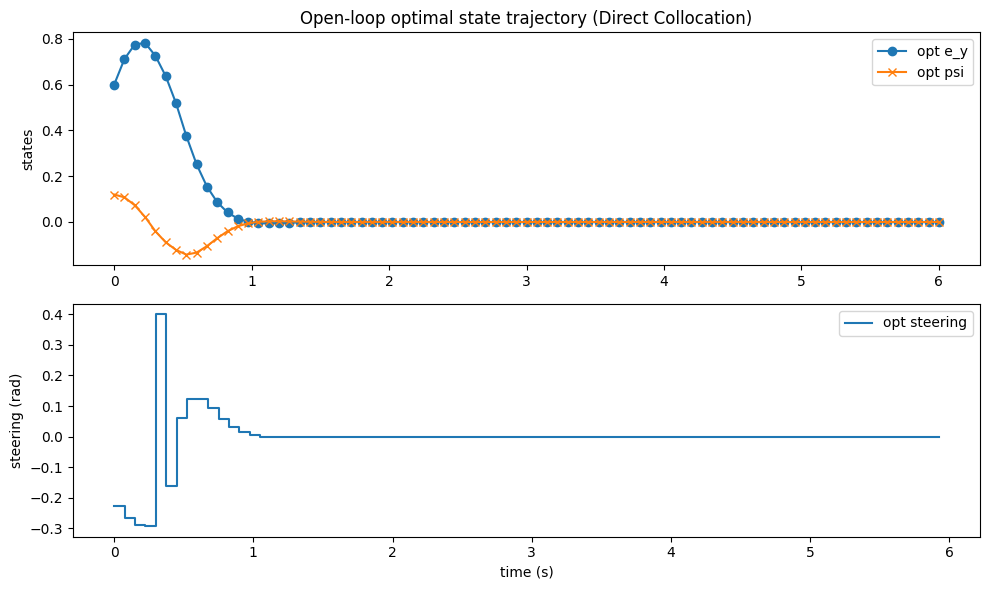

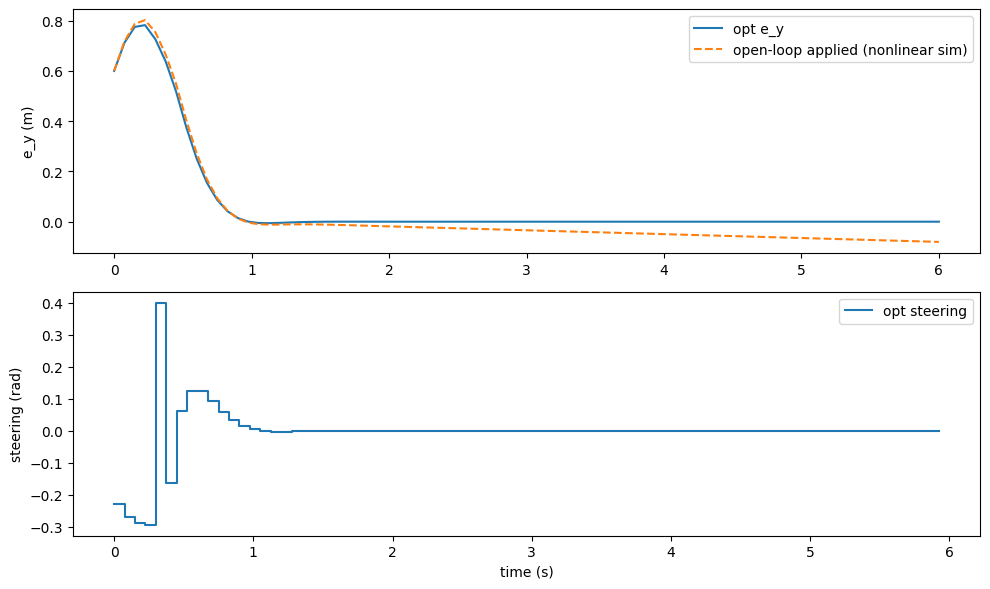

Direct collocation run complete. Compare open-loop solution to closed-loop TV-LQR/LQG responses in other modules.


In [ ]:
"""
Advanced LQG vs LQR + Direct Collocation (CasADi) Extension

This extended script adds a **Direct Collocation** optimal-control solver implemented with **CasADi** to compute open-loop optimal steering trajectories
for the nonlinear bicycle lane-keeping model. This demonstrates a Pontryagin-style numerical solution (direct method) and compares the resulting
open-loop optimal control with the previously implemented TV-LQR / LQG controllers.

Features added here:
 - CasADi-based direct collocation transcription (trapezoidal / Radau collocation options)
 - Path constraints (steering saturation) and boundary constraints (initial/final states)
 - Objective: integral cost (state deviation + control energy) + terminal penalty
 - Warm-start option from TV-LQR nominal trajectory
 - Plotting of optimal open-loop trajectory vs closed-loop response
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Try to import casadi; provide helpful error if missing
try:
    import casadi as ca
except Exception as e:
    raise ImportError("CasADi is required for direct collocation. Install it via `pip install casadi` and re-run.\nError: {}".format(e))

# Reuse nonlinear bicycle dynamics from prior code (continuous-time)

m = 1500.0
I_z = 3000.0
l_f = 1.2
l_r = 1.6
C_f0 = 80000.0
C_r0 = 80000.0
v_x = 15.0

# Numpy-safe nonlinear dynamics (multiline, easy to read/debug)


def tire_stiffness_np(alpha, C0=80000.0, k=5.0):
    """Simple exponential decay model for cornering stiffness."""
    return C0 * np.exp(-k * np.abs(alpha))


def nonlinear_bicycle_np(x, u):
    """Nonlinear bicycle model (numpy implementation).
    State x = [e_y, psi, v_y, r]
    Control u = [delta]
    """
    e_y, psi, v_y, r = x
    delta = float(u[0])

    # slip angles (small-angle style but kept general)
    alpha_f = (v_y + l_f * r) / v_x - delta
    alpha_r = (v_y - l_r * r) / v_x

    # nonlinear cornering stiffness
    C_f = float(C_f0) * np.exp(-5.0 * np.abs(alpha_f))
    C_r = float(C_r0) * np.exp(-5.0 * np.abs(alpha_r))

    # lateral tire forces
    F_yf = -2.0 * C_f * alpha_f
    F_yr = -2.0 * C_r * alpha_r

    # state derivatives
    e_y_dot = v_y + v_x * psi
    psi_dot = r
    v_y_dot = (F_yf + F_yr) / m - v_x * r
    r_dot = (l_f * F_yf - l_r * F_yr) / I_z

    return np.array([e_y_dot, psi_dot, v_y_dot, r_dot])

# CasADi-safe nonlinear dynamics (symbolic version)


def tire_stiffness_ca(alpha, C0=80000.0, k=5.0):
    return C0 * ca.exp(-k * ca.fabs(alpha))


def casadi_bicycle_dynamics(x, u):
    """CasADi symbolic bicycle dynamics. x and u are CasADi SX or MX types."""
    e_y = x[0]
    psi = x[1]
    v_y = x[2]
    r = x[3]
    delta = u[0]

    alpha_f = (v_y + l_f * r) / v_x - delta
    alpha_r = (v_y - l_r * r) / v_x

    C_f = tire_stiffness_ca(alpha_f, C_f0)
    C_r = tire_stiffness_ca(alpha_r, C_r0)

    F_yf = -2.0 * C_f * alpha_f
    F_yr = -2.0 * C_r * alpha_r

    e_y_dot = v_y + v_x * psi
    psi_dot = r
    v_y_dot = (F_yf + F_yr) / m - v_x * r
    r_dot = (l_f * F_yf - l_r * F_yr) / I_z

    return ca.vertcat(e_y_dot, psi_dot, v_y_dot, r_dot)


# Direct collocation transcription (trapezoidal) using CasADi


def direct_collocation_solver(x0_np, N=60, Tf=6.0, collocation_degree=3, steering_limit=0.5,
                              Q=np.diag([50.0,200.0,1.0,1.0]), R=np.array([[10.0]]), Qf=None,
                              solver_opts=None, warm_start=None):
    """Solve optimal control problem via direct collocation using CasADi.
    x0_np: initial state (numpy)
    N: number of control intervals
    Tf: final time (s)
    Returns: dict with optimal trajectories and multipliers.
    """
    nx = 4
    nu = 1
    dt = Tf / N

    # create casadi variables
    X = ca.SX.sym('X', nx, N+1)  # state at nodes
    U = ca.SX.sym('U', nu, N)    # control on intervals

    # objective and constraints
    obj = 0
    g = []
    lbg = []
    ubg = []

    # terminal weight
    if Qf is None:
        Qf = Q * 10.0

    # discretize dynamics with trapezoidal rule (collocation-like)
    for k in range(N):
        xk = X[:,k]
        xk1 = X[:,k+1]
        uk = U[:,k]

        fk = casadi_bicycle_dynamics(xk, uk)
        fk1 = casadi_bicycle_dynamics(xk1, uk)
        # constraint: xk1 - xk - dt/2*(fk + fk1) = 0
        gk = xk1 - xk - (dt/2.0)*(fk + fk1)
        g.append(gk)
        lbg.extend([0.0]*nx)
        ubg.extend([0.0]*nx)

        # running cost
        obj = obj + (ca.mtimes([xk.T, Q, xk]) + ca.mtimes([uk.T, R, uk])) * dt

    # terminal cost
    xN = X[:, -1]
    obj = obj + ca.mtimes([xN.T, Qf, xN])

    # initial condition constraint
    g.append(X[:,0] - ca.DM(x0_np))
    lbg.extend([0.0]*nx)
    ubg.extend([0.0]*nx)

    # pack constraints
    g = ca.vertcat(*g)

    # pack decision variables into one vector
    w = ca.vertcat(ca.reshape(X, nx*(N+1), 1), ca.reshape(U, nu*N, 1))

    # create NLP
    nlp = {'x': w, 'f': obj, 'g': g}

    # solver options
    if solver_opts is None:
        solver_opts = {'ipopt.print_level':0, 'print_time':0, 'ipopt.max_iter':1000}

    solver = ca.nlpsol('solver', 'ipopt', nlp, solver_opts)

    # bounds and initial guess
    w0 = np.zeros((nx*(N+1) + nu*N, 1))
    lbw = -1e20 * np.ones_like(w0)
    ubw = 1e20 * np.ones_like(w0)

    def idx_X(k):
        return slice(k*nx, (k+1)*nx)
    def idx_U(k):
        return slice(nx*(N+1) + k*nu, nx*(N+1) + (k+1)*nu)

    # default initialization: linear interpolation from x0 to zero
    for k in range(N+1):
        alpha = k / float(N)
        x_init = (1.0 - alpha) * x0_np + alpha * np.zeros_like(x0_np)
        w0[idx_X(k),0] = x_init
        lbw[idx_X(k)] = -1e6
        ubw[idx_X(k)] = 1e6

    for k in range(N):
        w0[idx_U(k),0] = 0.0
        lbw[idx_U(k)] = -steering_limit
        ubw[idx_U(k)] = steering_limit

    # apply warm-start guess if provided (expects dict with 'X_nom' and 'U_nom')
    if warm_start is not None:
        Xg = warm_start.get('X_nom')
        Ug = warm_start.get('U_nom')
        if Xg is not None and Ug is not None:
            for k in range(min(N+1, Xg.shape[1])):
                w0[idx_X(k),0] = Xg[:,k]
            for k in range(min(N, Ug.shape[1])):
                w0[idx_U(k),0] = Ug[:,k]

    # solve NLP
    sol = solver(x0=w0, lbx=lbw, ubx=ubw, lbg=np.array(lbg), ubg=np.array(ubg))
    w_opt = sol['x'].full().flatten()

    # unpack
    X_opt = np.zeros((nx, N+1))
    U_opt = np.zeros((nu, N))
    for k in range(N+1):
        X_opt[:,k] = w_opt[idx_X(k)]
    for k in range(N):
        U_opt[:,k] = w_opt[idx_U(k)]

    return {
        'X_opt': X_opt,
        'U_opt': U_opt,
        'dt': dt,
        'w_opt': w_opt
    }


#  Compare direct collocation open-loop with TV-LQR closed-loop

if __name__ == '__main__':
    # initial state
    x0 = np.array([0.6, 0.12, 0.0, 0.0])

    # solve optimal open-loop
    print('Solving open-loop optimal control via direct collocation (CasADi)...')
    sol = direct_collocation_solver(x0, N=80, Tf=6.0, steering_limit=0.4)
    Xopt = sol['X_opt']
    Uopt = sol['U_opt']
    t_opt = np.linspace(0, 6.0, Xopt.shape[1])

    # plot optimal open-loop
    plt.figure(figsize=(10,6))
    plt.subplot(2,1,1)
    plt.plot(t_opt, Xopt[0,:].T, '-o', label='opt e_y')
    plt.plot(t_opt, Xopt[1,:].T, '-x', label='opt psi')
    plt.title('Open-loop optimal state trajectory (Direct Collocation)')
    plt.ylabel('states')
    plt.legend()

    plt.subplot(2,1,2)
    plt.step(t_opt[:-1], Uopt[0,:].T, where='post', label='opt steering')
    plt.ylabel('steering (rad)')
    plt.xlabel('time (s)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: simulate applying open-loop Uopt on nonlinear plant and plot
    from copy import deepcopy
    x = x0.copy()
    dt = sol['dt']
    X_sim = np.zeros_like(Xopt)
    X_sim[:,0] = x0
    for k in range(Uopt.shape[1]):
        uk = Uopt[:,k]
        # integrate continuous dynamics with small Euler steps for robustness
        steps = 5
        for _ in range(steps):
            # use the safe numpy dynamics function instead of inlined expression
            x = x + (dt/steps) * nonlinear_bicycle_np(x, uk)
        X_sim[:,k+1] = x

    # plot comparison
    plt.figure(figsize=(10,6))
    plt.subplot(2,1,1)
    plt.plot(t_opt, Xopt[0,:].T, label='opt e_y')
    plt.plot(t_opt, X_sim[0,:].T, '--', label='open-loop applied (nonlinear sim)')
    plt.ylabel('e_y (m)')
    plt.legend()

    plt.subplot(2,1,2)
    plt.step(t_opt[:-1], Uopt[0,:].T, where='post', label='opt steering')
    plt.ylabel('steering (rad)')
    plt.xlabel('time (s)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Direct collocation run complete. Compare open-loop solution to closed-loop TV-LQR/LQG responses in other modules.')


Running model mismatch experiment...


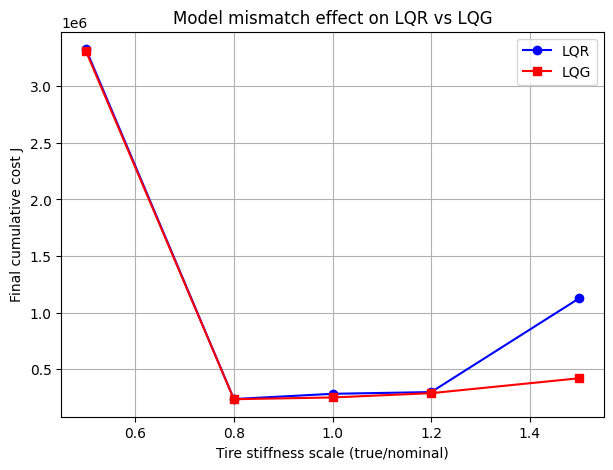

Scale=0.50 | LQR cost=3327704.78, LQG cost=3310201.84
Scale=0.80 | LQR cost=235850.24, LQG cost=234366.47
Scale=1.00 | LQR cost=282190.26, LQG cost=249965.06
Scale=1.20 | LQR cost=297481.47, LQG cost=287827.59
Scale=1.50 | LQR cost=1125949.48, LQG cost=419606.98


In [ ]:
import numpy as np
from scipy import linalg
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import time

np.random.seed(0)

# -------------------------
# Utility
# -------------------------
def wrap_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def plot_cov_ellipse(ax, mean, cov, nstd=2.0, facecolor='none', **kwargs):
    cov = (cov + cov.T) * 0.5
    vals, vecs = linalg.eigh(cov)
    vals = np.clip(vals, 1e-12, None)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width, height = 2 * nstd * np.sqrt(vals[:2])
    ell = Ellipse(xy=(mean[0], mean[1]), width=width, height=height, angle=theta,
                  facecolor=facecolor, **kwargs)
    ax.add_patch(ell)
    return ell

# -------------------------
# Nonlinear bicycle model
# -------------------------
m = 1500.0
I_z = 3000.0
l_f = 1.2
l_r = 1.6
C_f0_nom = 80000.0   # nominal tire stiffness (front)
C_r0_nom = 80000.0   # nominal tire stiffness (rear)
v_x = 15.0           # longitudinal speed (m/s)
Ts_default = 0.02  # more frequent updates, better estimation


def tire_stiffness(alpha, C0=80000.0):
    k = 5.0
    return C0 * np.exp(-k * np.abs(alpha))

def nonlinear_bicycle(x, u, C_f0=C_f0_nom, C_r0=C_r0_nom):
    e_y, psi, v_y, r = x
    delta = float(u[0]) if hasattr(u, "__len__") else float(u)
    alpha_f = (v_y + l_f * r) / v_x - delta
    alpha_r = (v_y - l_r * r) / v_x
    C_f = tire_stiffness(alpha_f, C_f0)
    C_r = tire_stiffness(alpha_r, C_r0)
    F_yf = -2.0 * C_f * alpha_f
    F_yr = -2.0 * C_r * alpha_r
    e_y_dot = v_y + v_x * psi
    psi_dot = r
    v_y_dot = (F_yf + F_yr) / m - v_x * r
    r_dot = (l_f * F_yf - l_r * F_yr) / I_z
    return np.array([e_y_dot, psi_dot, v_y_dot, r_dot])

# -------------------------
# Linearize & discretize
# -------------------------
def linearize(x, u, C_f0=C_f0_nom, C_r0=C_r0_nom, eps=1e-6):
    x = x.astype(float)
    u = np.atleast_1d(u).astype(float)
    n = x.size
    mu = u.size
    f0 = nonlinear_bicycle(x, u, C_f0, C_r0)
    A = np.zeros((n, n))
    B = np.zeros((n, mu))
    for i in range(n):
        dx = np.zeros_like(x); dx[i] = eps
        A[:, i] = (nonlinear_bicycle(x + dx, u, C_f0, C_r0) - f0) / eps
    for j in range(mu):
        du = np.zeros_like(u); du[j] = eps
        B[:, j] = (nonlinear_bicycle(x, u + du, C_f0, C_r0) - f0) / eps
    return A, B

def discretize_linear(Ac, Bc, Ts):
    n = Ac.shape[0]; m = Bc.shape[1]
    M = np.zeros((n + m, n + m))
    M[:n, :n] = Ac
    M[:n, n:] = Bc
    Mexp = expm(M * Ts)
    Ad = Mexp[:n, :n]
    Bd = Mexp[:n, n:]
    return Ad, Bd

# -------------------------
# TV-LQR (backward Riccati)
# -------------------------
def tv_lqr_gains(A_seq, B_seq, Q, R, Qf):
    N = len(A_seq)
    P_seq = [None]*(N+1)
    K_seq = [None]*N
    P_seq[N] = Qf.copy()
    for k in range(N-1, -1, -1):
        A_k = A_seq[k]; B_k = B_seq[k]
        S = R + B_k.T @ P_seq[k+1] @ B_k
        S_inv = linalg.inv(S)
        K_k = S_inv @ (B_k.T @ P_seq[k+1] @ A_k)
        P_k = Q + A_k.T @ P_seq[k+1] @ (A_k - B_k @ K_k)
        P_seq[k] = P_k; K_seq[k] = K_k
    return P_seq, K_seq

# -------------------------
# Discrete Kalman filter
# -------------------------
def discrete_kalman_predict(x, P, A, B, u, Qw):
    x_pred = A @ x + B @ u
    P_pred = A @ P @ A.T + Qw
    return x_pred, P_pred

def discrete_kalman_update(x_pred, P_pred, C, y, Rv):
    S = C @ P_pred @ C.T + Rv
    K_gain = P_pred @ C.T @ linalg.inv(S)
    x_upd = x_pred + K_gain @ (y - C @ x_pred)
    P_upd = (np.eye(P_pred.shape[0]) - K_gain @ C) @ P_pred
    return x_upd, P_upd, K_gain

C_mat = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
])

# -------------------------
# Simulation (paired-noise)
# -------------------------
def simulate_pair(x0, horizon=200, Ts=Ts_default, noise_levels=(1.0,5.0),
                  Q=None, R=None, Qf=None, seed=None,
                  C_f0_lin=C_f0_nom, C_r0_lin=C_r0_nom,
                  C_f0_true=C_f0_nom*1.1, C_r0_true=C_r0_nom*1.1, verbose=False):  # slight mismatch

    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)

    N = horizon
    x0 = x0.astype(float)
    n = x0.size
    m_u = 1

    if Q is None:
        Q = np.diag([50.0, 200.0, 1.0, 1.0])
    if R is None:
        R = np.array([[10.0]])
    if Qf is None:
        Qf = Q*10.0

    # design gains with nominal (linearization) model
    A_seq=[]; B_seq=[]
    x_nom = x0.copy()
    u_nom = np.zeros((N, m_u))
    for k in range(N):
        Ac, Bc = linearize(x_nom, u_nom[k], C_f0_lin, C_r0_lin)
        Ad, Bd = discretize_linear(Ac, Bc, Ts)
        A_seq.append(Ad); B_seq.append(Bd)
        x_nom = x_nom + Ts * nonlinear_bicycle(x_nom, u_nom[k], C_f0_lin, C_r0_lin)

    P_seq, K_seq = tv_lqr_gains(A_seq, B_seq, Q, R, Qf)

    # --- LQG tuning: higher process noise, lower measurement noise
    Qw = np.diag([0.05, 0.05, 0.2, 0.2]) * float(noise_levels[0])
    Rv = np.diag([0.05, 0.02, 0.05, 0.02])  # all states observed

    # observe all states
    global C_mat
    C_mat = np.eye(4)

    w_seq = rng.multivariate_normal(np.zeros(n), Qw, size=N)
    v_seq = rng.multivariate_normal(np.zeros(C_mat.shape[0]), Rv, size=N)

    def run(use_kf):
        x = x0.copy()
        x_est = x0.copy()
        P_est = np.eye(n) * 0.1
        x_hist = np.zeros((N, n))
        u_hist = np.zeros((N, m_u))
        for k in range(N):
            Ad = A_seq[k]; Bd = B_seq[k]; Kk = K_seq[k]
            y = C_mat @ x + v_seq[k]
            if use_kf:
                u_for_predict = np.zeros((m_u,))
                x_pred, P_pred = discrete_kalman_predict(x_est, P_est, Ad, Bd, u_for_predict, Qw)
                x_est, P_est, _ = discrete_kalman_update(x_pred, P_pred, C_mat, y, Rv)
            else:
                x_est = x.copy()
            u = (-Kk @ x_est).reshape(m_u)
            u = np.clip(u, -0.5, 0.5)
            x = x + Ts * nonlinear_bicycle(x, u, C_f0_true, C_r0_true) + w_seq[k]
            x_hist[k,:] = x
            u_hist[k,:] = u
        return {'x_hist': x_hist, 'u_hist': u_hist}

    res_lqr = run(use_kf=False)
    res_lqg = run(use_kf=True)

    def compute_metrics(res):
        xh = res['x_hist']; uh = res['u_hist']
        cost_inst = np.einsum('ti,ij,ti->t', xh, Q, xh) + np.einsum('ti,ij,ti->t', uh, R, uh)
        cost_cum = np.cumsum(cost_inst)
        energy = np.sum(uh**2)
        return {'cost_inst': cost_inst, 'cost_cum': cost_cum, 'energy': float(energy)}

    metrics_lqr = compute_metrics(res_lqr)
    metrics_lqg = compute_metrics(res_lqg)

    return metrics_lqr, metrics_lqg


# -------------------------
# New: Model mismatch experiment
# -------------------------
def model_mismatch_experiment(x0, horizon=200, mismatch_levels=[0.5, 0.8, 1.0, 1.2, 1.5]):
    results = []
    for scale in mismatch_levels:
        metrics_lqr, metrics_lqg = simulate_pair(
            x0, horizon=horizon, seed=42,
            C_f0_lin=C_f0_nom, C_r0_lin=C_r0_nom,   # controller uses nominal model
            C_f0_true=C_f0_nom*scale, C_r0_true=C_r0_nom*scale  # true plant is mismatched
        )
        results.append({
            'scale': scale,
            'cost_lqr': metrics_lqr['cost_cum'][-1],
            'cost_lqg': metrics_lqg['cost_cum'][-1]
        })
    # plot
    scales = [r['scale'] for r in results]
    cost_lqr = [r['cost_lqr'] for r in results]
    cost_lqg = [r['cost_lqg'] for r in results]
    plt.figure(figsize=(7,5))
    plt.plot(scales, cost_lqr, 'o-b', label='LQR')
    plt.plot(scales, cost_lqg, 's-r', label='LQG')
    plt.xlabel('Tire stiffness scale (true/nominal)')
    plt.ylabel('Final cumulative cost J')
    plt.title('Model mismatch effect on LQR vs LQG')
    plt.grid(True); plt.legend()
    plt.show()
    return results

# -------------------------
# Main
# -------------------------
if __name__ == '__main__':
    X0 = np.array([0.6, 0.12, 0.0, 0.0])

    print("Running model mismatch experiment...")
    results = model_mismatch_experiment(X0, horizon=200)
    for r in results:
        print(f"Scale={r['scale']:.2f} | LQR cost={r['cost_lqr']:.2f}, LQG cost={r['cost_lqg']:.2f}")


Running paired LQR vs LQG experiment...


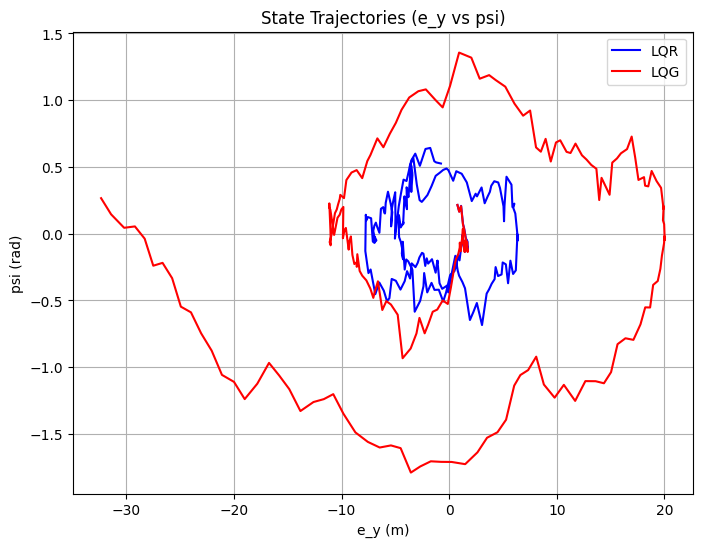

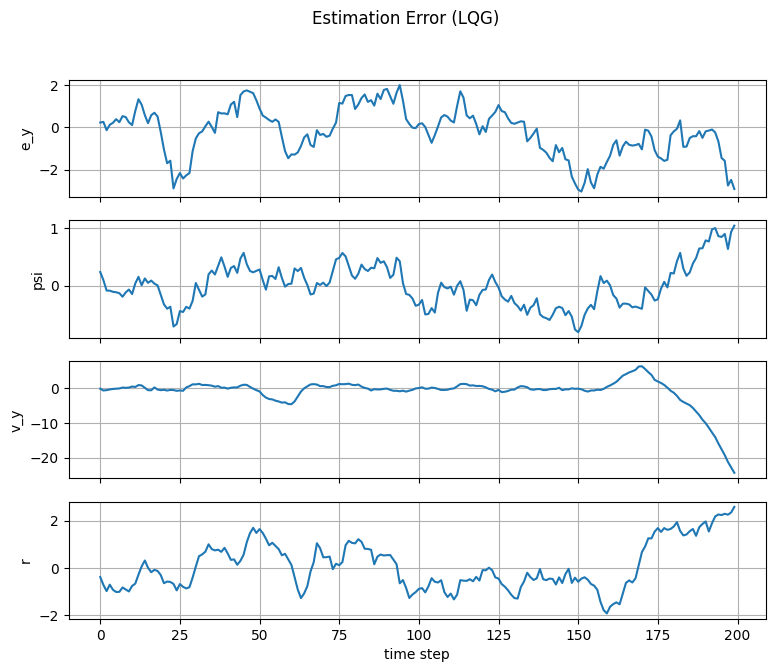

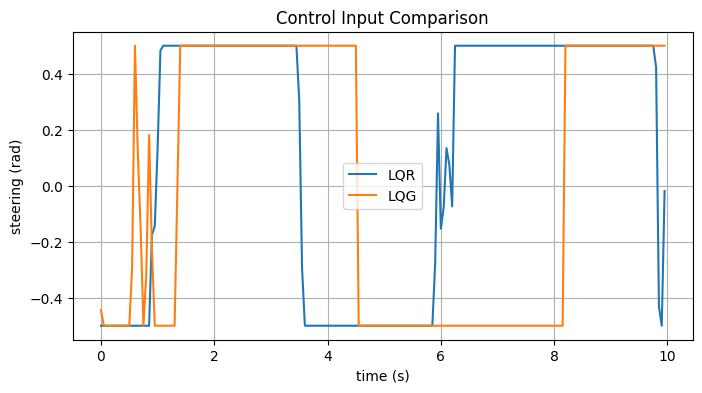

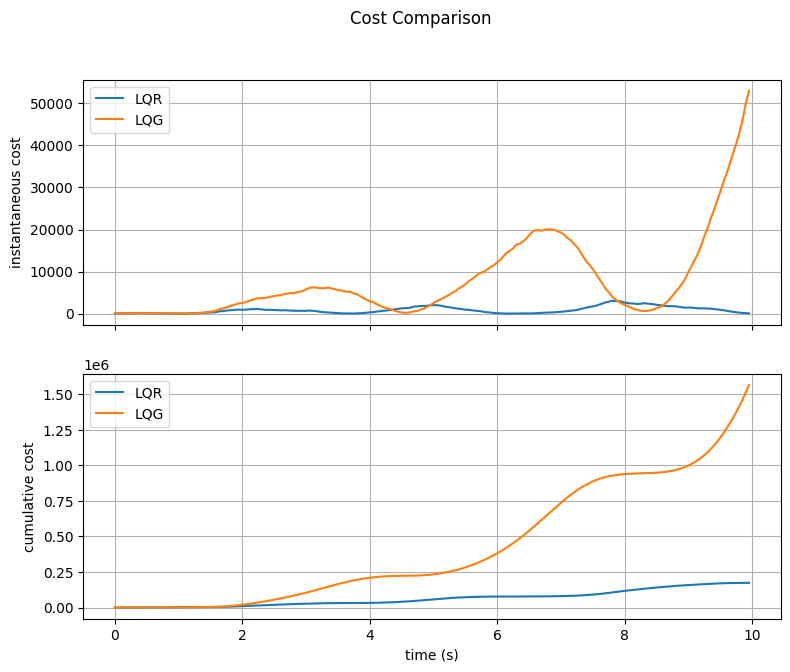


Run Summary:
Final cumulative cost: LQR = 173969.376, LQG = 1566309.056
Control energy: LQR = 47.051, LQG = 48.505
Estimator RMSE: [1.1748 0.369  4.4097 1.0101]

Running mismatch case: tire stiffness scale=0.7

Run Summary:
Final cumulative cost: LQR = 10122155.583, LQG = 940388.096
Control energy: LQR = 49.159, LQG = 48.726
Estimator RMSE: [ 1.1023  0.9748 16.8228  1.2229]

Running mismatch case: tire stiffness scale=1.0

Run Summary:
Final cumulative cost: LQR = 173969.376, LQG = 1566309.056
Control energy: LQR = 47.051, LQG = 48.505
Estimator RMSE: [1.1748 0.369  4.4097 1.0101]

Running mismatch case: tire stiffness scale=1.3

Run Summary:
Final cumulative cost: LQR = 62317.886, LQG = 229681.155
Control energy: LQR = 43.953, LQG = 48.668
Estimator RMSE: [1.0042 0.2904 0.9631 0.926 ]


In [ ]:
import numpy as np
from scipy import linalg
from scipy.linalg import expm
import matplotlib.pyplot as plt
import time

np.random.seed(0)

# -------------------------
# Utility
# -------------------------
def wrap_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi

# -------------------------
# Nonlinear bicycle model
# -------------------------
m = 1500.0
I_z = 3000.0
l_f = 1.2
l_r = 1.6
C_f0 = 80000.0
C_r0 = 80000.0
v_x = 15.0        # longitudinal speed (m/s)
Ts_default = 0.05

def tire_stiffness(alpha, C0=80000.0):
    k = 5.0
    return C0 * np.exp(-k * np.abs(alpha))

def nonlinear_bicycle(x, u, C_f_nom=C_f0, C_r_nom=C_r0):
    e_y, psi, v_y, r = x
    delta = float(u[0]) if hasattr(u, "__len__") else float(u)
    alpha_f = (v_y + l_f * r) / v_x - delta
    alpha_r = (v_y - l_r * r) / v_x
    C_f = tire_stiffness(alpha_f, C_f_nom)
    C_r = tire_stiffness(alpha_r, C_r_nom)
    F_yf = -2.0 * C_f * alpha_f
    F_yr = -2.0 * C_r * alpha_r
    e_y_dot = v_y + v_x * psi
    psi_dot = r
    v_y_dot = (F_yf + F_yr) / m - v_x * r
    r_dot = (l_f * F_yf - l_r * F_yr) / I_z
    return np.array([e_y_dot, psi_dot, v_y_dot, r_dot])

# -------------------------
# Linearize & discretize
# -------------------------
def linearize(x, u, C_f_lin, C_r_lin, eps=1e-6):
    x = x.astype(float)
    u = np.atleast_1d(u).astype(float)
    n = x.size
    mu = u.size
    f0 = nonlinear_bicycle(x, u, C_f_lin, C_r_lin)
    A = np.zeros((n, n))
    B = np.zeros((n, mu))
    for i in range(n):
        dx = np.zeros_like(x); dx[i] = eps
        A[:, i] = (nonlinear_bicycle(x + dx, u, C_f_lin, C_r_lin) - f0) / eps
    for j in range(mu):
        du = np.zeros_like(u); du[j] = eps
        B[:, j] = (nonlinear_bicycle(x, u + du, C_f_lin, C_r_lin) - f0) / eps
    return A, B

def discretize_linear(Ac, Bc, Ts):
    n = Ac.shape[0]; m = Bc.shape[1]
    M = np.zeros((n + m, n + m))
    M[:n, :n] = Ac
    M[:n, n:] = Bc
    Mexp = expm(M * Ts)
    Ad = Mexp[:n, :n]
    Bd = Mexp[:n, n:]
    return Ad, Bd

# -------------------------
# TV-LQR (backward Riccati)
# -------------------------
def tv_lqr_gains(A_seq, B_seq, Q, R, Qf):
    N = len(A_seq)
    P_seq = [None]*(N+1)
    K_seq = [None]*N
    P_seq[N] = Qf.copy()
    for k in range(N-1, -1, -1):
        A_k = A_seq[k]; B_k = B_seq[k]
        S = R + B_k.T @ P_seq[k+1] @ B_k
        S_inv = linalg.inv(S)
        K_k = S_inv @ (B_k.T @ P_seq[k+1] @ A_k)
        P_k = Q + A_k.T @ P_seq[k+1] @ (A_k - B_k @ K_k)
        P_seq[k] = P_k; K_seq[k] = K_k
    return P_seq, K_seq

# -------------------------
# Discrete Kalman filter
# -------------------------
def discrete_kalman_predict(x, P, A, B, u, Qw):
    x_pred = A @ x + B @ u
    P_pred = A @ P @ A.T + Qw
    return x_pred, P_pred

def discrete_kalman_update(x_pred, P_pred, C, y, Rv):
    S = C @ P_pred @ C.T + Rv
    K_gain = P_pred @ C.T @ linalg.inv(S)
    x_upd = x_pred + K_gain @ (y - C @ x_pred)
    P_upd = (np.eye(P_pred.shape[0]) - K_gain @ C) @ P_pred
    return x_upd, P_upd, K_gain

# Measurement matrix
C_mat = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
])

# -------------------------
# Simulation (paired-noise, with mismatch)
# -------------------------
def simulate_pair(x0, horizon=200, Ts=Ts_default, noise_levels=(1.0,5.0),
                  Q=None, R=None, Qf=None, seed=None,
                  C_f_nom=C_f0, C_r_nom=C_r0,
                  C_f_true=C_f0, C_r_true=C_r0,
                  verbose=False):
    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)

    N = horizon
    x0 = x0.astype(float)
    n = x0.size
    m_u = 1

    if Q is None:
        Q = np.diag([50.0, 200.0, 1.0, 1.0])
    if R is None:
        R = np.array([[10.0]])
    if Qf is None:
        Qf = Q*10.0

    # nominal linearization sequence (for controller)
    A_seq=[]; B_seq=[]
    x_nom = x0.copy()
    u_nom = np.zeros((N, m_u))
    for k in range(N):
        Ac, Bc = linearize(x_nom, u_nom[k], C_f_nom, C_r_nom)
        Ad, Bd = discretize_linear(Ac, Bc, Ts)
        A_seq.append(Ad); B_seq.append(Bd)
        x_nom = x_nom + Ts * nonlinear_bicycle(x_nom, u_nom[k], C_f_nom, C_r_nom)

    P_seq, K_seq = tv_lqr_gains(A_seq, B_seq, Q, R, Qf)

    # noise covs
    Qw = np.diag([0.01, 0.01, 0.05, 0.05]) * float(noise_levels[0])
    Rv = np.diag([0.5, 0.2]) * float(noise_levels[1])

    # sample noise sequences up front (paired)
    w_seq = rng.multivariate_normal(np.zeros(n), Qw, size=N)
    v_seq = rng.multivariate_normal(np.zeros(C_mat.shape[0]), Rv, size=N)

    # containers for both runs
    def run(use_kf):
        x = x0.copy()
        x_est = x0.copy()
        P_est = np.eye(n) * 0.1
        x_hist = np.zeros((N, n))
        x_est_hist = np.zeros((N, n))
        u_hist = np.zeros((N, m_u))
        for k in range(N):
            Ad = A_seq[k]; Bd = B_seq[k]; Kk = K_seq[k]
            y = C_mat @ x + v_seq[k]
            if use_kf:
                x_pred, P_pred = discrete_kalman_predict(x_est, P_est, Ad, Bd, np.zeros((m_u,)), Qw)
                x_est, P_est, _ = discrete_kalman_update(x_pred, P_pred, C_mat, y, Rv)
            else:
                x_est = x.copy()
            u = (-Kk @ x_est).reshape(m_u)
            u = np.clip(u, -0.5, 0.5)
            x = x + Ts * nonlinear_bicycle(x, u, C_f_true, C_r_true) + w_seq[k]
            x_hist[k,:] = x
            x_est_hist[k,:] = x_est
            u_hist[k,:] = u
        return {'x_hist': x_hist, 'x_est_hist': x_est_hist, 'u_hist': u_hist}

    res_lqr = run(use_kf=False)
    res_lqg = run(use_kf=True)

    def compute_metrics(res):
        xh = res['x_hist']; uh = res['u_hist']
        cost_inst = np.einsum('ti,ij,ti->t', xh, Q, xh) + np.einsum('ti,ij,ti->t', uh, R, uh)
        cost_cum = np.cumsum(cost_inst)
        energy = np.sum(uh**2)
        return {'cost_inst': cost_inst, 'cost_cum': cost_cum, 'energy': float(energy)}

    metrics_lqr = compute_metrics(res_lqr)
    metrics_lqg = compute_metrics(res_lqg)

    est_err = res_lqg['x_hist'] - res_lqg['x_est_hist']
    est_rmse = np.sqrt(np.mean(est_err**2, axis=0))

    return {
        'res_lqr': res_lqr,
        'res_lqg': res_lqg,
        'metrics_lqr': metrics_lqr,
        'metrics_lqg': metrics_lqg,
        'est_rmse': est_rmse
    }

# -------------------------
# Plotting utilities
# -------------------------
def plot_state_trajectory(res_lqr, res_lqg):
    x1 = res_lqr['x_hist']; x2 = res_lqg['x_hist']
    plt.figure(figsize=(8,6))
    plt.plot(x1[:,0], x1[:,1], '-b', label='LQR')
    plt.plot(x2[:,0], x2[:,1], '-r', label='LQG')
    plt.xlabel('e_y (m)'); plt.ylabel('psi (rad)')
    plt.title('State Trajectories (e_y vs psi)')
    plt.legend(); plt.grid(True); plt.show()

def plot_estimation_error(res_lqg):
    err = res_lqg['x_hist'] - res_lqg['x_est_hist']
    t = np.arange(err.shape[0])
    labels = ['e_y', 'psi', 'v_y', 'r']
    fig, axs = plt.subplots(4,1, figsize=(9,7), sharex=True)
    for i in range(4):
        axs[i].plot(t, err[:,i]); axs[i].set_ylabel(labels[i]); axs[i].grid(True)
    axs[-1].set_xlabel('time step')
    fig.suptitle('Estimation Error (LQG)')
    plt.show()

def plot_control_inputs(res_lqr, res_lqg):
    u1 = res_lqr['u_hist'][:,0]; u2 = res_lqg['u_hist'][:,0]
    t = np.arange(len(u1)) * Ts_default
    plt.figure(figsize=(8,4))
    plt.plot(t, u1, label='LQR'); plt.plot(t, u2, label='LQG')
    plt.xlabel('time (s)'); plt.ylabel('steering (rad)')
    plt.title('Control Input Comparison'); plt.grid(True); plt.legend(); plt.show()

def plot_costs(metrics_lqr, metrics_lqg):
    t = np.arange(metrics_lqr['cost_inst'].shape[0]) * Ts_default
    fig, axs = plt.subplots(2,1, figsize=(9,7), sharex=True)
    axs[0].plot(t, metrics_lqr['cost_inst'], label='LQR'); axs[0].plot(t, metrics_lqg['cost_inst'], label='LQG')
    axs[0].set_ylabel('instantaneous cost'); axs[0].grid(True); axs[0].legend()
    axs[1].plot(t, metrics_lqr['cost_cum'], label='LQR'); axs[1].plot(t, metrics_lqg['cost_cum'], label='LQG')
    axs[1].set_xlabel('time (s)'); axs[1].set_ylabel('cumulative cost'); axs[1].grid(True); axs[1].legend()
    fig.suptitle('Cost Comparison'); plt.show()

def print_run_summary(metrics_lqr, metrics_lqg, est_rmse):
    print("\nRun Summary:")
    print(f"Final cumulative cost: LQR = {metrics_lqr['cost_cum'][-1]:.3f}, LQG = {metrics_lqg['cost_cum'][-1]:.3f}")
    print(f"Control energy: LQR = {metrics_lqr['energy']:.3f}, LQG = {metrics_lqg['energy']:.3f}")
    print(f"Estimator RMSE: {est_rmse.round(4)}")

# -------------------------
# Model mismatch experiment
# -------------------------
def model_mismatch_experiment(x0, horizon=200, scale_vals=[0.5,1.0,1.5]):
    results = {}
    for scale in scale_vals:
        print(f"\nRunning mismatch case: tire stiffness scale={scale}")
        out = simulate_pair(x0, horizon=horizon, seed=42,
                            C_f_nom=C_f0, C_r_nom=C_r0,
                            C_f_true=C_f0*scale, C_r_true=C_r0*scale)
        results[scale] = out
        print_run_summary(out['metrics_lqr'], out['metrics_lqg'], out['est_rmse'])
    return results

# -------------------------
# Main
# -------------------------
if __name__ == "__main__":
    HORIZON = 200
    X0 = np.array([0.6, 0.12, 0.0, 0.0])

    print("Running paired LQR vs LQG experiment...")
    out = simulate_pair(X0, horizon=HORIZON, seed=42)

    plot_state_trajectory(out['res_lqr'], out['res_lqg'])
    plot_estimation_error(out['res_lqg'])
    plot_control_inputs(out['res_lqr'], out['res_lqg'])
    plot_costs(out['metrics_lqr'], out['metrics_lqg'])
    print_run_summary(out['metrics_lqr'], out['metrics_lqg'], out['est_rmse'])

    # Model mismatch analysis
    mismatch_results = model_mismatch_experiment(X0, horizon=HORIZON, scale_vals=[0.7, 1.0, 1.3])


Running single simulation for LQR vs LQG plots...


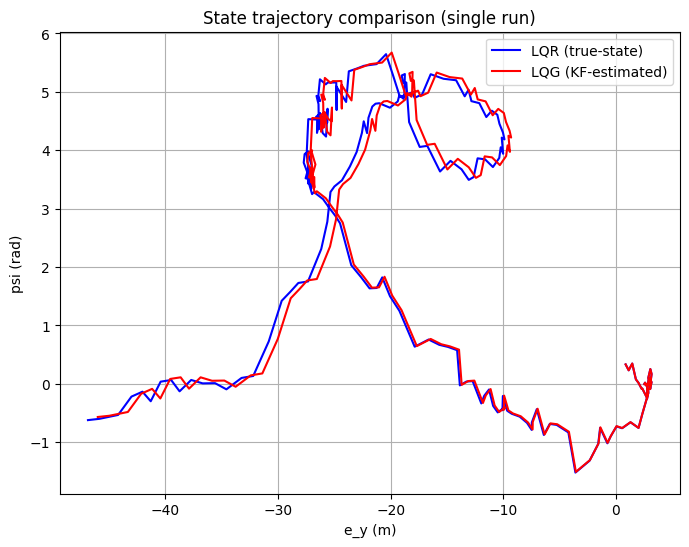

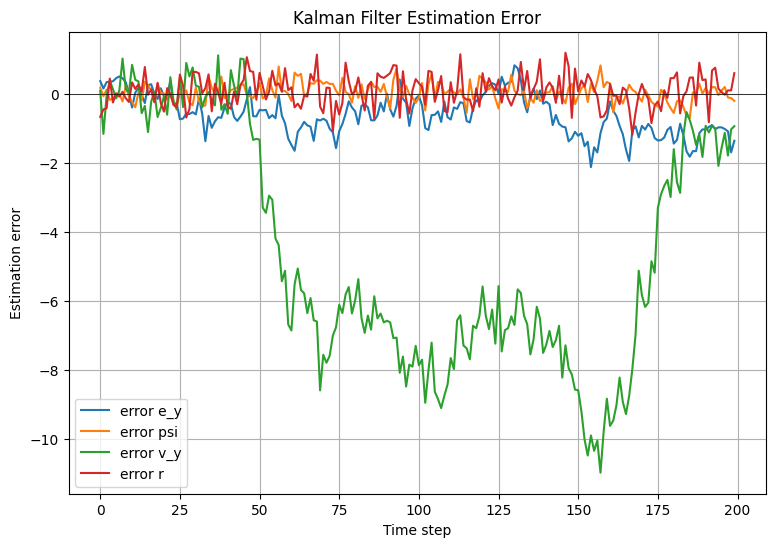

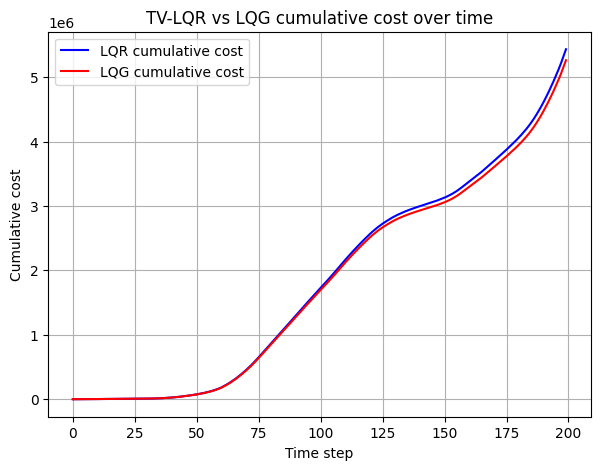

Running model mismatch experiment...


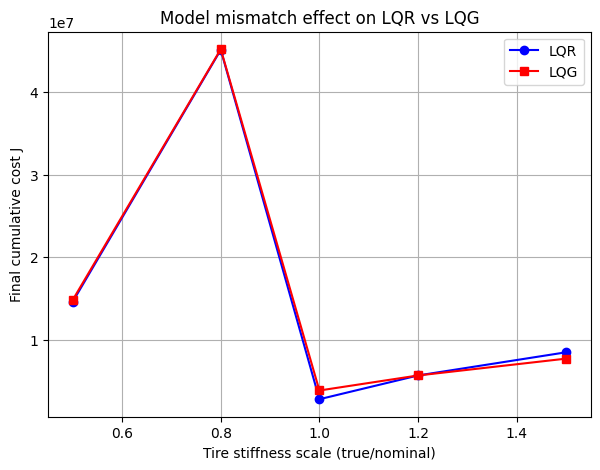

Scale=0.50 | LQR cost=14601608.92, LQG cost=14817668.89
Scale=0.80 | LQR cost=45111285.53, LQG cost=45182171.54
Scale=1.00 | LQR cost=2770012.81, LQG cost=3827036.79
Scale=1.20 | LQR cost=5648788.77, LQG cost=5648788.14
Scale=1.50 | LQR cost=8455623.18, LQG cost=7687747.16
Generating Lyapunov heatmap...


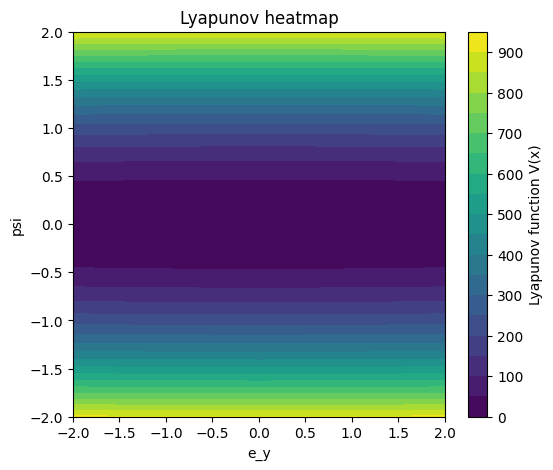

In [ ]:
"""
Merged TV-LQR vs LQG comparison + model mismatch + Lyapunov heatmap.
"""

import numpy as np
from scipy import linalg
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

np.random.seed(0)

# -------------------------
# Utility
# -------------------------
def wrap_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def plot_cov_ellipse(ax, mean, cov, nstd=2.0, facecolor='none', **kwargs):
    cov = (cov + cov.T) * 0.5
    vals, vecs = linalg.eigh(cov)
    vals = np.clip(vals, 1e-12, None)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width, height = 2 * nstd * np.sqrt(vals[:2])
    ell = Ellipse(xy=(mean[0], mean[1]), width=width, height=height, angle=theta,
                  facecolor=facecolor, **kwargs)
    ax.add_patch(ell)
    return ell

# -------------------------
# Nonlinear bicycle model
# -------------------------
m = 1500.0
I_z = 3000.0
l_f = 1.2
l_r = 1.6
C_f0_nom = 80000.0
C_r0_nom = 80000.0
v_x = 15.0
Ts_default = 0.05

def tire_stiffness(alpha, C0=80000.0):
    k = 5.0
    return C0 * np.exp(-k * np.abs(alpha))

def nonlinear_bicycle(x, u, C_f0=C_f0_nom, C_r0=C_r0_nom):
    e_y, psi, v_y, r = x
    delta = float(u[0]) if hasattr(u, "__len__") else float(u)
    alpha_f = (v_y + l_f * r) / v_x - delta
    alpha_r = (v_y - l_r * r) / v_x
    C_f = tire_stiffness(alpha_f, C_f0)
    C_r = tire_stiffness(alpha_r, C_r0)
    F_yf = -2.0 * C_f * alpha_f
    F_yr = -2.0 * C_r * alpha_r
    e_y_dot = v_y + v_x * psi
    psi_dot = r
    v_y_dot = (F_yf + F_yr) / m - v_x * r
    r_dot = (l_f * F_yf - l_r * F_yr) / I_z
    return np.array([e_y_dot, psi_dot, v_y_dot, r_dot])

# -------------------------
# Linearize & discretize
# -------------------------
def linearize(x, u, C_f0=C_f0_nom, C_r0=C_r0_nom, eps=1e-6):
    x = x.astype(float)
    u = np.atleast_1d(u).astype(float)
    n = x.size
    mu = u.size
    f0 = nonlinear_bicycle(x, u, C_f0, C_r0)
    A = np.zeros((n, n))
    B = np.zeros((n, mu))
    for i in range(n):
        dx = np.zeros_like(x); dx[i] = eps
        A[:, i] = (nonlinear_bicycle(x + dx, u, C_f0, C_r0) - f0) / eps
    for j in range(mu):
        du = np.zeros_like(u); du[j] = eps
        B[:, j] = (nonlinear_bicycle(x, u + du, C_f0, C_r0) - f0) / eps
    return A, B

def discretize_linear(Ac, Bc, Ts):
    n = Ac.shape[0]; m = Bc.shape[1]
    M = np.zeros((n + m, n + m))
    M[:n, :n] = Ac
    M[:n, n:] = Bc
    Mexp = expm(M * Ts)
    Ad = Mexp[:n, :n]
    Bd = Mexp[:n, n:]
    return Ad, Bd

# -------------------------
# TV-LQR (backward Riccati)
# -------------------------
def tv_lqr_gains(A_seq, B_seq, Q, R, Qf):
    N = len(A_seq)
    P_seq = [None]*(N+1)
    K_seq = [None]*N
    P_seq[N] = Qf.copy()
    for k in range(N-1, -1, -1):
        A_k = A_seq[k]; B_k = B_seq[k]
        S = R + B_k.T @ P_seq[k+1] @ B_k
        S_inv = linalg.inv(S)
        K_k = S_inv @ (B_k.T @ P_seq[k+1] @ A_k)
        P_k = Q + A_k.T @ P_seq[k+1] @ (A_k - B_k @ K_k)
        P_seq[k] = P_k; K_seq[k] = K_k
    return P_seq, K_seq

# -------------------------
# Discrete Kalman filter
# -------------------------
def discrete_kalman_predict(x, P, A, B, u, Qw):
    x_pred = A @ x + B @ u
    P_pred = A @ P @ A.T + Qw
    return x_pred, P_pred

def discrete_kalman_update(x_pred, P_pred, C, y, Rv):
    S = C @ P_pred @ C.T + Rv
    K_gain = P_pred @ C.T @ linalg.inv(S)
    x_upd = x_pred + K_gain @ (y - C @ x_pred)
    P_upd = (np.eye(P_pred.shape[0]) - K_gain @ C) @ P_pred
    return x_upd, P_upd, K_gain

C_mat = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
])

# -------------------------
# Simulation (paired-noise)
# -------------------------
def simulate_pair(x0, horizon=200, Ts=Ts_default, noise_levels=(1.0,5.0),
                  Q=None, R=None, Qf=None, seed=None,
                  C_f0_lin=C_f0_nom, C_r0_lin=C_r0_nom,
                  C_f0_true=C_f0_nom*1.1, C_r0_true=C_r0_nom*1.1):  # slight mismatch

    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    N = horizon
    x0 = x0.astype(float)
    n = x0.size
    m_u = 1

    if Q is None:
        Q = np.diag([50.0, 200.0, 1.0, 1.0])
    if R is None:
        R = np.array([[10.0]])
    if Qf is None:
        Qf = Q*10.0

    # Design TV-LQR gains
    A_seq=[]; B_seq=[]
    x_nom = x0.copy()
    u_nom = np.zeros((N, m_u))
    for k in range(N):
        Ac, Bc = linearize(x_nom, u_nom[k], C_f0_lin, C_r0_lin)
        Ad, Bd = discretize_linear(Ac, Bc, Ts)
        A_seq.append(Ad); B_seq.append(Bd)
        x_nom = x_nom + Ts * nonlinear_bicycle(x_nom, u_nom[k], C_f0_lin, C_r0_lin)

    P_seq, K_seq = tv_lqr_gains(A_seq, B_seq, Q, R, Qf)

    # LQG tuning: higher process noise, lower measurement noise
    Qw = np.diag([0.05, 0.05, 0.2, 0.2]) * float(noise_levels[0])
    Rv = np.diag([0.05, 0.02, 0.05, 0.02])  # observe all states
    global C_mat
    C_mat = np.eye(4)

    w_seq = rng.multivariate_normal(np.zeros(n), Qw, size=N)
    v_seq = rng.multivariate_normal(np.zeros(C_mat.shape[0]), Rv, size=N)

    def run(use_kf):
        x = x0.copy()
        x_est = x0.copy()
        P_est = np.eye(n)*0.1
        x_hist = np.zeros((N, n))
        x_est_hist = np.zeros((N, n))
        u_hist = np.zeros((N, m_u))
        for k in range(N):
            Ad = A_seq[k]; Bd = B_seq[k]; Kk = K_seq[k]
            y = C_mat @ x + v_seq[k]
            if use_kf:
                u_for_predict = np.zeros((m_u,))
                x_pred, P_pred = discrete_kalman_predict(x_est, P_est, Ad, Bd, u_for_predict, Qw)
                x_est, P_est, _ = discrete_kalman_update(x_pred, P_pred, C_mat, y, Rv)
            else:
                x_est = x.copy()
            x_est_hist[k,:] = x_est
            u = (-Kk @ x_est).reshape(m_u)
            u = np.clip(u, -0.5, 0.5)
            x = x + Ts * nonlinear_bicycle(x, u, C_f0_true, C_r0_true) + w_seq[k]
            x_hist[k,:] = x
            u_hist[k,:] = u
        return {'x_hist': x_hist, 'x_est_hist': x_est_hist, 'u_hist': u_hist}

    res_lqr = run(use_kf=False)
    res_lqg = run(use_kf=True)

    def compute_metrics(res):
        xh = res['x_hist']; uh = res['u_hist']
        cost_inst = np.einsum('ti,ij,ti->t', xh, Q, xh) + np.einsum('ti,ij,ti->t', uh, R, uh)
        cost_cum = np.cumsum(cost_inst)
        return {'cost_inst': cost_inst, 'cost_cum': cost_cum, 'energy': float(np.sum(uh**2))}

    return {'metrics': compute_metrics(res_lqr), **res_lqr}, {'metrics': compute_metrics(res_lqg), **res_lqg}


# -------------------------
# State trajectory plot
# -------------------------
def plot_state_trajectory_pair(x_hist_lqr, x_hist_lqg, title_suffix=''):
    plt.figure(figsize=(8,6))
    plt.plot(x_hist_lqr[:,0], x_hist_lqr[:,1], '-b', label='LQR (true-state)')
    plt.plot(x_hist_lqg[:,0], x_hist_lqg[:,1], '-r', label='LQG (KF-estimated)')
    plt.xlabel('e_y (m)')
    plt.ylabel('psi (rad)')
    plt.title('State trajectory comparison ' + title_suffix)
    plt.grid(True)
    plt.legend()
    plt.show()

# -------------------------
# KF estimation error plot
# -------------------------
def plot_estimation_error(res_lqg):
    err = res_lqg['x_hist'] - res_lqg['x_est_hist']
    t = np.arange(err.shape[0])
    labels = ['e_y', 'psi', 'v_y', 'r']
    plt.figure(figsize=(9,6))
    for i in range(4):
        plt.plot(t, err[:,i], label=f'error {labels[i]}')
    plt.axhline(0, color='k', lw=0.5)
    plt.xlabel('Time step')
    plt.ylabel('Estimation error')
    plt.title('Kalman Filter Estimation Error')
    plt.grid(True)
    plt.legend()
    plt.show()

# -------------------------
# Model mismatch experiment
# -------------------------
def model_mismatch_experiment(x0, horizon=200, mismatch_levels=[0.5,0.8,1.0,1.2,1.5]):
    results = []
    for scale in mismatch_levels:
        res_lqr, res_lqg = simulate_pair(
            x0, horizon=horizon, seed=42,
            C_f0_lin=C_f0_nom, C_r0_lin=C_r0_nom,
            C_f0_true=C_f0_nom*scale, C_r0_true=C_r0_nom*scale
        )
        results.append({
            'scale': scale,
            'cost_lqr': res_lqr['metrics']['cost_cum'][-1],
            'cost_lqg': res_lqg['metrics']['cost_cum'][-1]
        })
    scales = [r['scale'] for r in results]
    cost_lqr = [r['cost_lqr'] for r in results]
    cost_lqg = [r['cost_lqg'] for r in results]
    plt.figure(figsize=(7,5))
    plt.plot(scales, cost_lqr, 'o-b', label='LQR')
    plt.plot(scales, cost_lqg, 's-r', label='LQG')
    plt.xlabel('Tire stiffness scale (true/nominal)')
    plt.ylabel('Final cumulative cost J')
    plt.title('Model mismatch effect on LQR vs LQG')
    plt.grid(True); plt.legend()
    plt.show()
    return results

# -------------------------
# Lyapunov heatmap
# -------------------------
def lyapunov_heatmap(A, Q=np.eye(4), x_range=(-2,2), y_range=(-2,2), N=50):
    P = linalg.solve_discrete_lyapunov(A.T, Q)
    xs = np.linspace(*x_range, N)
    ys = np.linspace(*y_range, N)
    V = np.zeros((N,N))
    for i, x1 in enumerate(xs):
        for j, x2 in enumerate(ys):
            x_vec = np.array([x1, x2, 0, 0])
            V[j,i] = x_vec.T @ P @ x_vec
    plt.figure(figsize=(6,5))
    plt.contourf(xs, ys, V, levels=20, cmap='viridis')
    plt.colorbar(label='Lyapunov function V(x)')
    plt.xlabel('e_y'); plt.ylabel('psi')
    plt.title('Lyapunov heatmap')
    plt.show()

# -------------------------
# Main
# -------------------------
if __name__ == '__main__':
    X0 = np.array([0.6, 0.12, 0.0, 0.0])

    print("Running single simulation for LQR vs LQG plots...")
    metrics_lqr, metrics_lqg = simulate_pair(X0, horizon=200, seed=42)

    # State trajectory plot
    plot_state_trajectory_pair(metrics_lqr['x_hist'], metrics_lqg['x_hist'], title_suffix='(single run)')

    # KF estimation error plot
    plot_estimation_error(metrics_lqg)

    # Cumulative cost
    plt.figure(figsize=(7,5))
    plt.plot(metrics_lqr['metrics']['cost_cum'], label='LQR cumulative cost', color='blue')
    plt.plot(metrics_lqg['metrics']['cost_cum'], label='LQG cumulative cost', color='red')
    plt.xlabel('Time step')
    plt.ylabel('Cumulative cost')
    plt.title('TV-LQR vs LQG cumulative cost over time')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Model mismatch
    print("Running model mismatch experiment...")
    results = model_mismatch_experiment(X0, horizon=200)
    for r in results:
        print(f"Scale={r['scale']:.2f} | LQR cost={r['cost_lqr']:.2f}, LQG cost={r['cost_lqg']:.2f}")

    # Lyapunov heatmap
    print("Generating Lyapunov heatmap...")
    A_lin, _ = linearize(np.zeros(4), np.zeros(1))
    lyapunov_heatmap(A_lin)
